In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import math
from fractions import Fraction

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from surrogate_matlab import *
from fda_rof_funcs_v2 import *
import torch
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64)

print("device:", device)


device: cuda


In [3]:
import itertools
import matplotlib.pyplot as plt
import torch


@torch.no_grad()
def plot_learned_constellation(mapper, ml, device=None, annotate=True, title=None):
    """
    Plot learned constellation of NeuralQAMMapper.

    mapper expects input shape [B, Ns, ml]
    """
    if device is None:
        device = next(mapper.parameters()).device

    mapper.eval()

    # all possible bit patterns: [M, ml]
    patterns = list(itertools.product([0, 1], repeat=ml))
    bits = torch.tensor(patterns, dtype=torch.float64, device=device)

    # add fake batch and symbol dimensions -> [1, M, ml]
    bits = bits.unsqueeze(0)

    # mapper output: [1, M]
    sym = mapper(bits)[0]

    sym_np = sym.detach().cpu().numpy()
    xs = sym_np.real
    ys = sym_np.imag

    plt.figure(figsize=(6, 6))
    plt.scatter(xs, ys, s=80)

    if annotate:
        for i, b in enumerate(patterns):
            label = "".join(str(v) for v in b)
            plt.text(xs[i] + 0.02, ys[i] + 0.02, label, fontsize=8)

    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)
    plt.xlabel("In-phase")
    plt.ylabel("Quadrature")
    plt.title(title or f"Learned Constellation ({2**ml}-ary)")
    plt.grid(True)
    plt.axis("equal")
    plt.show()

In [4]:
class FDAROFSurrogateWithRRC(nn.Module):
    def __init__(self,
                 Rt: float,
                 init_a1: float,
                 init_b1: float,
                 init_a2: float,
                 init_b2: float,
                 init_k: float,
                 OFDM_bandwidth: float = 5e9,
                 G: float = 2e9,
                 sps: int = 8,
                 roll: float = 0.1,
                 span: int = 64,
                 num_taps: int = 63,
                 snr_db: float = 10.0):
        super().__init__()

        self.da = ContinuousDABlockTorch(
            Rt=Rt,
            init_a1=init_a1,
            init_b1=init_b1,
            init_a2=init_a2,
            init_b2=init_b2,
        )
        self.k_param = PositiveScalar(init_k)

        self.cfg = add_discrete_freqs_to_fdm_config(
            build_fdm_config_from_rt(
                Rt=Rt,
                OFDM_bandwidth=OFDM_bandwidth,
                G=G,
                sps=sps,
            )
        )

        self.sps = sps
        self.roll = roll
        self.span = span
        self.num_taps = num_taps
        self.snr_db = snr_db

    @property
    def k(self):
        return self.k_param.value

    def forward(self, ofdm_sig: torch.Tensor):
        # 1) continuous DA mod, ofdm_sig is normalized first before DA mod
        sig_n1, sig_n2, mod_aux = self.da.mod(ofdm_sig)
        

        # 2) RRC TX
        tx_rrc_1 = apply_rrc_tx_torch(sig_n1, beta=self.roll, sps=self.sps, span=self.span)
        tx_rrc_2 = apply_rrc_tx_torch(sig_n2, beta=self.roll, sps=self.sps, span=self.span)

        # 3) TX-side resample
        tx1, tx2 = branch_resample_tx_from_cfg(
            tx_rrc_1, tx_rrc_2, self.cfg, num_taps=self.num_taps
        )


        L_sig_inner = tx1.numel()
        L_sig_outer = tx2.numel()
        tx1 = complex_awgn(tx1, self.snr_db)
        tx2 = complex_awgn(tx2, self.snr_db)

        tx_fdm, fdm_aux = fdm_combine_from_cfg(
            tx1, tx2, self.k, self.cfg, length_mode="pad_to_max"
        )

        rx1_mix, rx2_mix = fdm_separate_from_cfg(
            tx_fdm, self.k, self.cfg
        )


        rx1_mix = rx1_mix[:L_sig_inner]
        rx2_mix = rx2_mix[:L_sig_outer]


        rx1_rs, rx2_rs = branch_resample_rx_from_cfg(
            rx1_mix, rx2_mix, self.cfg, num_taps=self.num_taps
        )


        rx1_rrc = apply_rrc_rx_torch(rx1_rs, beta=self.roll, sps=self.sps, span=self.span)
        rx2_rrc = apply_rrc_rx_torch(rx2_rs, beta=self.roll, sps=self.sps, span=self.span)


        rx1_sym = rx1_rrc[::self.sps]
        rx2_sym = rx2_rrc[::self.sps]


        rx1_sym = pad_or_crop_to_length(rx1_sym, sig_n1.numel())
        rx2_sym = pad_or_crop_to_length(rx2_sym, sig_n2.numel())


        x_hat, rx_seg1, rx_seg2, demod_aux = self.da.demod(
            rx1_sym, rx2_sym,
            scale1=mod_aux["scale1"],
            scale2=mod_aux["scale2"],
        )

        aux = {
            "cfg": self.cfg,
            "mod_aux": mod_aux,
            "fdm_aux": fdm_aux,
            "demod_aux": demod_aux,
            "sig_n1": sig_n1,
            "sig_n2": sig_n2,
            "tx_rrc_1": tx_rrc_1,
            "tx_rrc_2": tx_rrc_2,
            "tx1": tx1,
            "tx2": tx2,
            "rx1_rs": rx1_rs,
            "rx2_rs": rx2_rs,
            "rx1_rrc": rx1_rrc,
            "rx2_rrc": rx2_rrc,
            "rx1_sym": rx1_sym,
            "rx2_sym": rx2_sym,
            "tx_fdm": tx_fdm,
            "rx_fdm": tx_fdm,
        }

        return x_hat, rx_seg1, rx_seg2, aux

In [5]:

def normalize_unit_power_complex(x: torch.Tensor, eps=1e-12):

    p = torch.mean(torch.abs(x) ** 2)
    return x / torch.sqrt(p + eps)


def complex_mmse_gain(tx: torch.Tensor, rx: torch.Tensor, eps=1e-12):

    tx_n = normalize_unit_power_complex(tx, eps)
    rx_n = normalize_unit_power_complex(rx, eps)

    denom = torch.sum(torch.abs(tx_n) ** 2).real + eps
    numer = torch.sum(torch.conj(tx_n) * rx_n)
    h = numer / denom
    return h, tx_n, rx_n


def snr_db_complex_gain(tx: torch.Tensor, rx: torch.Tensor, eps=1e-12):

    h, tx_n, rx_n = complex_mmse_gain(tx, rx, eps=eps)

    ref = h * tx_n
    err = rx_n - ref

    ps = torch.mean(torch.abs(ref) ** 2)
    pn = torch.mean(torch.abs(err) ** 2)

    snr_lin = ps / (pn + eps)
    snr_db = 10.0 * torch.log10(snr_lin + eps)

    aux = {
        "h": h.detach(),
        "ps": ps.detach().item(),
        "pn": pn.detach().item(),
        "snr_lin": snr_lin.detach().item(),
        "snr_db": snr_db.detach().item(),
    }
    return snr_db, aux

In [6]:

def bits_to_symbol_blocks_torch(bits, ml):

    if bits.dim() == 1:
        bits = bits.unsqueeze(0)
    B, total_bits = bits.shape
    if total_bits % ml != 0:
        raise ValueError(f"total_bits={total_bits} not divisible by ml={ml}")
    return bits.reshape(B, total_bits // ml, ml)


def add_cp_torch(x_freq, gilen):

    cp = x_freq[:, -gilen:, :]
    return torch.cat([cp, x_freq], dim=1)


def remove_cp_torch(x_td_cp, gilen):

    return x_td_cp[:, gilen:, :]


def flatten_fortran_last2(x):

    return x.transpose(1, 2).reshape(x.shape[0], -1)


def unflatten_fortran_last2(x, A, C):

    B = x.shape[0]
    return x.reshape(B, C, A).transpose(1, 2)


class NeuralQAMMapper(nn.Module):

    def __init__(self, ml, hidden=64):
        super().__init__()
        self.ml = ml
        self.net = nn.Sequential(
            nn.Linear(ml, hidden),
            nn.GELU(),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, 2),
        )

    def forward(self, bits_block):

        B, Ns, ml = bits_block.shape
        x = bits_block.reshape(B * Ns, ml)
        y = self.net(x)
        y = y.reshape(B, Ns, 2)

        sym = torch.complex(y[..., 0], y[..., 1])

        power = torch.mean(torch.abs(sym) ** 2)
        sym = sym / torch.sqrt(power + 1e-12)
        return sym


class NeuralQAMDemapper(nn.Module):

    def __init__(self, ml, hidden=64):
        super().__init__()
        self.ml = ml
        self.net = nn.Sequential(
            nn.Linear(2, hidden),
            nn.GELU(),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, ml),
        )

    def forward(self, symbols):

        x = torch.stack([symbols.real, symbols.imag], dim=-1)
        B, Ns, _ = x.shape
        y = self.net(x.reshape(B * Ns, 2))
        return y.reshape(B, Ns, self.ml)


class OFDMModulatorTorch(nn.Module):

    def __init__(self, cfg=OFDM_CFG):
        super().__init__()
        self.cfg = cfg
        self.para = cfg["para"]
        self.fftlen = cfg["fftlen"]
        self.nd = cfg["nd"]
        self.gilen = cfg["gilen"]
        self.fftlen2 = cfg["fftlen2"]

        if self.para != self.fftlen:
            raise NotImplementedError(
                "Current torch OFDM wrapper assumes para == fftlen, "
                "matching your current notebook setting."
            )

    def forward(self, qam_symbols):

        B, Ns = qam_symbols.shape
        expected = self.para * self.nd
        if Ns != expected:
            raise ValueError(f"qam_symbols has {Ns} symbols, expected {expected}")

        x_freq = unflatten_fortran_last2(qam_symbols, self.fftlen, self.nd)  # [B, fftlen, nd]
        y_td = torch.fft.ifft(x_freq, n=self.fftlen, dim=1)
        y_cp = add_cp_torch(y_td, self.gilen)
        serial = flatten_fortran_last2(y_cp)

        aux = {
            "x_freq": x_freq,
            "y_td": y_td,
            "y_cp": y_cp,
        }
        return serial, aux


class OFDMDemodulatorTorch(nn.Module):

    def __init__(self, cfg=OFDM_CFG):
        super().__init__()
        self.cfg = cfg
        self.para = cfg["para"]
        self.fftlen = cfg["fftlen"]
        self.nd = cfg["nd"]
        self.gilen = cfg["gilen"]
        self.fftlen2 = cfg["fftlen2"]

        if self.para != self.fftlen:
            raise NotImplementedError(
                "Current torch OFDM wrapper assumes para == fftlen, "
                "matching your current notebook setting."
            )

    def forward(self, ofdm_serial):

        B, L = ofdm_serial.shape
        expected = self.fftlen2 * self.nd
        if L != expected:
            raise ValueError(f"ofdm_serial length {L}, expected {expected}")

        y_cp = unflatten_fortran_last2(ofdm_serial, self.fftlen2, self.nd)   # [B, fftlen2, nd]
        y_td = remove_cp_torch(y_cp, self.gilen)                              # [B, fftlen, nd]
        x_freq_hat = torch.fft.fft(y_td, n=self.fftlen, dim=1)
        qam_hat = flatten_fortran_last2(x_freq_hat)

        aux = {
            "y_cp": y_cp,
            "y_td": y_td,
            "x_freq_hat": x_freq_hat,
        }
        return qam_hat, aux


class EndToEndNeuralFDAROF(nn.Module):

    def __init__(
        self,
        Rt: float,
        init_a1: float,
        init_b1: float,
        init_a2: float,
        init_b2: float,
        init_k: float,
        mapper_hidden: int = 64,
        demapper_hidden: int = 64,
        cfg=OFDM_CFG,
        OFDM_bandwidth: float = 5e9,
        G: float = 2e9,
        sps: int = 8,
        roll: float = 0.1,
        span: int = 64,
        num_taps: int = 63,
        snr_db: float = 24.0,
    ):
        super().__init__()
        self.cfg = cfg
        self.ml = cfg["ml"]
        self.total_bits = cfg["para"] * cfg["nd"] * cfg["ml"]
        self.num_symbols = cfg["para"] * cfg["nd"]

        self.mapper = NeuralQAMMapper(self.ml, hidden=mapper_hidden)
        self.ofdm_mod = OFDMModulatorTorch(cfg=cfg)

        self.channel = FDAROFSurrogateWithRRC(
            Rt=Rt,
            init_a1=init_a1,
            init_b1=init_b1,
            init_a2=init_a2,
            init_b2=init_b2,
            init_k=init_k,
            OFDM_bandwidth=OFDM_bandwidth,
            G=G,
            sps=sps,
            roll=roll,
            span=span,
            num_taps=num_taps,
            snr_db=snr_db,
        )

        self.ofdm_demod = OFDMDemodulatorTorch(cfg=cfg)
        self.demapper = NeuralQAMDemapper(self.ml, hidden=demapper_hidden)

    def forward(self, bits):

        if bits.dim() == 1:
            bits = bits.unsqueeze(0)

        bits_block = bits_to_symbol_blocks_torch(bits, self.ml)  

        tx_qam = self.mapper(bits_block)                         # [B, Ns]
        tx_ofdm, tx_aux = self.ofdm_mod(tx_qam)                  # [B, L]

        rx_ofdm_list = []
        ch_aux_list = []
        for b in range(tx_ofdm.shape[0]):
            x_hat, rx_seg1, rx_seg2, aux = self.channel(tx_ofdm[b])
            rx_ofdm_list.append(x_hat)
            ch_aux_list.append({
                "rx_seg1": rx_seg1,
                "rx_seg2": rx_seg2,
                "aux": aux,
            })
        rx_ofdm = torch.stack(rx_ofdm_list, dim=0)              # [B, L]

        rx_qam, rx_aux = self.ofdm_demod(rx_ofdm)               # [B, Ns]
        bit_logits = self.demapper(rx_qam)                      # [B, Ns, ml]

        aux = {
            "bits_block": bits_block,
            "tx_qam": tx_qam,
            "tx_ofdm": tx_ofdm,
            "tx_aux": tx_aux,
            "rx_ofdm": rx_ofdm,
            "rx_qam": rx_qam,
            "rx_aux": rx_aux,
            "channel_aux_list": ch_aux_list,
        }
        return bit_logits, aux


def sample_random_bits_batch(batch_size, cfg=OFDM_CFG, device=None, seed=None):
    if seed is not None:
        np.random.seed(seed)

    total_bits = cfg["para"] * cfg["nd"] * cfg["ml"]
    bits = np.random.randint(0, 2, size=(batch_size, total_bits), dtype=int)
    bits = torch.from_numpy(bits).to(torch.float64)
    if device is not None:
        bits = bits.to(device)
    return bits


def load_parabits_tensor(parabits_path="../Baseline/parabits.mat", cfg=OFDM_CFG, device=None):
    bits = load_parabits_mat(parabits_path).reshape(-1)
    expected = cfg["para"] * cfg["nd"] * cfg["ml"]
    if bits.size != expected:
        raise ValueError(f"parabits length={bits.size}, expected={expected}")
    bits = torch.from_numpy(bits.astype(np.float64)).unsqueeze(0)
    if device is not None:
        bits = bits.to(device)
    return bits


def bit_error_rate_from_logits(bit_logits, target_bits):

    pred = (torch.sigmoid(bit_logits) >= 0.5).to(torch.float64)
    tgt = bits_to_symbol_blocks_torch(target_bits, bit_logits.shape[-1]).to(torch.float64)
    ber = torch.mean((pred != tgt).to(torch.float64))
    return ber.item()


def compute_e2e_bce_loss(model, bits):

    bit_logits, aux = model(bits)

    target = bits_to_symbol_blocks_torch(bits, model.ml).to(bit_logits.dtype)
    bce = F.binary_cross_entropy_with_logits(bit_logits, target)

    ber = bit_error_rate_from_logits(bit_logits, bits)

    tx_qam = aux["tx_qam"]
    rx_qam = aux["rx_qam"]
    qam_mse = torch.mean(torch.abs(tx_qam - rx_qam) ** 2)

    tx_ofdm = aux["tx_ofdm"]
    rx_ofdm = aux["rx_ofdm"]
    ofdm_mse = torch.mean(torch.abs(tx_ofdm - rx_ofdm) ** 2)

    stats = {
        "loss": bce.detach().item(),
        "ber": ber,
        "qam_mse": qam_mse.detach().item(),
        "ofdm_mse": ofdm_mse.detach().item(),
    }


    stats["a1"] = model.channel.da.a1.item()
    stats["b1"] = model.channel.da.b1.item()
    stats["a2"] = model.channel.da.a2.item()
    stats["b2"] = model.channel.da.b2.item()
    stats["k"] = model.channel.k.item()

    return bce, stats
def compute_e2e_joint_loss(model, bits, lambda_sym=0.01):

    bit_logits, aux = model(bits)

    target = bits_to_symbol_blocks_torch(bits, model.ml).to(bit_logits.dtype)
    bit_loss = F.binary_cross_entropy_with_logits(bit_logits, target)

    ber = bit_error_rate_from_logits(bit_logits, bits)

    tx_ofdm = aux["tx_ofdm"]   # [B, Ns] complex
    rx_ofdm = aux["rx_ofdm"]   # [B, Ns] complex
    tx_qam = aux["tx_qam"]       # [B, Ns] complex
    rx_qam = aux["rx_qam"]       # [B, Ns] complex

    snr_sym_db, snr_aux = snr_db_complex_gain(
        tx_ofdm.reshape(-1),
        rx_ofdm.reshape(-1),
    )


    sym_loss = -snr_sym_db


    total_loss = bit_loss + lambda_sym * sym_loss

    qam_mse = torch.mean(torch.abs(tx_qam - rx_qam) ** 2)

    ofdm_mse = torch.mean(torch.abs(tx_ofdm - rx_ofdm) ** 2)

    stats = {
        "loss": total_loss.detach().item(),
        "bit_loss": bit_loss.detach().item(),
        "sym_loss": sym_loss.detach().item(),
        "ber": ber,
        "snr_sym_db": snr_aux["snr_db"],
        "qam_mse": qam_mse.detach().item(),
        "ofdm_mse": ofdm_mse.detach().item(),
        "a1": model.channel.da.a1.item(),
        "b1": model.channel.da.b1.item(),
        "a2": model.channel.da.a2.item(),
        "b2": model.channel.da.b2.item(),
        "k": model.channel.k.item(),
    }

    return total_loss, stats

@torch.no_grad()
def validate_e2e_on_parabits(model, parabits_path="../Baseline/parabits.mat", cfg=OFDM_CFG, device=None):
    if device is None:
        device = next(model.parameters()).device
    bits = load_parabits_tensor(parabits_path=parabits_path, cfg=cfg, device=device)
    model.eval()
    loss, stats = compute_e2e_bce_loss(model, bits)
    return loss.item(), stats
@torch.no_grad()
def validate_e2e_joint_on_parabits(
    model,
    parabits_path="../Baseline/parabits.mat",
    cfg=OFDM_CFG,
    device=None,
    lambda_sym=0.01,
):
    if device is None:
        device = next(model.parameters()).device

    bits = load_parabits_tensor(
        parabits_path=parabits_path,
        cfg=cfg,
        device=device,
    )

    model.eval()
    loss, stats = compute_e2e_joint_loss(model, bits, lambda_sym=lambda_sym)
    return loss.item(), stats
best_snr_sym = -float("inf")
best_step = -1
import copy
import torch

def train_e2e_neural_modem(
    model,
    num_steps=200,
    batch_size=8,
    lr=1e-3,
    lambda_sym=0.01,
    print_every=20,
    grad_clip=None,
    parabits_path="../Baseline/parabits.mat",
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "loss": [],
        "bit_loss": [],
        "sym_loss": [],
        "ber": [],
        "snr_sym_db": [],
        "qam_mse": [],
        "ofdm_mse": [],
        "val_loss": [],
        "val_bit_loss": [],
        "val_sym_loss": [],
        "val_ber": [],
        "val_snr_sym_db": [],
        "val_qam_mse": [],
        "val_ofdm_mse": [],
        "a1": [],
        "b1": [],
        "a2": [],
        "b2": [],
        "k": [],
    }

    # -----------------------------
    # best trackers
    # -----------------------------
    best_val_ber = float("inf")
    best_val_ber_step = -1
    best_state_by_ber = None

    best_train_snr_sym = -float("inf")
    best_train_snr_sym_step = -1
    best_state_train_snr = None

    best_val_snr_sym = -float("inf")
    best_val_snr_sym_step = -1
    best_state_val_snr = None

    device = next(model.parameters()).device

    for step in range(1, num_steps + 1):
        model.train()
        optimizer.zero_grad()


        bits = sample_random_bits_batch(
            batch_size=batch_size,
            cfg=model.cfg,
            device=device,
            seed=step,
        )

        # bits = load_parabits_tensor(
        #     parabits_path=parabits_path,
        #     cfg=model.cfg,
        #     device=device,
        # )

        loss, stats = compute_e2e_joint_loss(
            model,
            bits,
            lambda_sym=lambda_sym,
        )
        loss.backward()

        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        optimizer.step()

        # -----------------------------
        # record train stats
        # -----------------------------
        history["loss"].append(stats["loss"])
        history["bit_loss"].append(stats["bit_loss"])
        history["sym_loss"].append(stats["sym_loss"])
        history["ber"].append(stats["ber"])
        history["snr_sym_db"].append(stats["snr_sym_db"])
        history["qam_mse"].append(stats["qam_mse"])
        history["ofdm_mse"].append(stats["ofdm_mse"])
        history["a1"].append(stats["a1"])
        history["b1"].append(stats["b1"])
        history["a2"].append(stats["a2"])
        history["b2"].append(stats["b2"])
        history["k"].append(stats["k"])

        # -----------------------------
        # update best train snr_sym
        # -----------------------------
        if stats["snr_sym_db"] > best_train_snr_sym:
            best_train_snr_sym = stats["snr_sym_db"]
            best_train_snr_sym_step = step
            best_state_train_snr = copy.deepcopy(model.state_dict())

        # -----------------------------
        # validation
        # -----------------------------
        if step % print_every == 0 or step == 1 or step == num_steps:
            val_loss, val_stats = validate_e2e_joint_on_parabits(
                model,
                parabits_path=parabits_path,
                cfg=model.cfg,
                device=device,
                lambda_sym=lambda_sym,
            )

            history["val_loss"].append(val_loss)
            history["val_bit_loss"].append(val_stats["bit_loss"])
            history["val_sym_loss"].append(val_stats["sym_loss"])
            history["val_ber"].append(val_stats["ber"])
            history["val_snr_sym_db"].append(val_stats["snr_sym_db"])
            history["val_qam_mse"].append(val_stats["qam_mse"])
            history["val_ofdm_mse"].append(val_stats["ofdm_mse"])

            # best by BER
            if val_stats["ber"] < best_val_ber:
                best_val_ber = val_stats["ber"]
                best_val_ber_step = step
                best_state_by_ber = copy.deepcopy(model.state_dict())

            # best by validation snr_sym
            if val_stats["snr_sym_db"] > best_val_snr_sym:
                best_val_snr_sym = val_stats["snr_sym_db"]
                best_val_snr_sym_step = step
                best_state_val_snr = copy.deepcopy(model.state_dict())

            print(
                f"step {step:4d} | "
                f"train_loss={stats['loss']:.6f} | "
                f"bit_loss={stats['bit_loss']:.6f} | "
                f"snr_sym={stats['snr_sym_db']:.4f} dB | "
                f"train_ber={stats['ber']:.6e} | "
                f"val_loss={val_loss:.6f} | "
                f"val_bit_loss={val_stats['bit_loss']:.6f} | "
                f"val_snr_sym={val_stats['snr_sym_db']:.4f} dB | "
                f"val_ber={val_stats['ber']:.6e} | "
                f"best_train_snr={best_train_snr_sym:.4f} dB @ {best_train_snr_sym_step} | "
                f"best_val_snr={best_val_snr_sym:.4f} dB @ {best_val_snr_sym_step} | "
                f"a1={model.channel.da.a1.item():.4f} | "
                f"b1={model.channel.da.b1.item():.4f} | "
                f"a2={model.channel.da.a2.item():.4f} | "
                f"b2={model.channel.da.b2.item():.4f} | "
                f"k={model.channel.k.item():.4f}"
            )

    # -----------------------------
    # save summary into history
    # -----------------------------
    history["best_val_ber"] = best_val_ber
    history["best_val_ber_step"] = best_val_ber_step
    history["best_state_by_ber"] = best_state_by_ber

    history["best_train_snr_sym_db"] = best_train_snr_sym
    history["best_train_snr_sym_step"] = best_train_snr_sym_step
    history["best_state_train_snr"] = best_state_train_snr

    history["best_val_snr_sym_db"] = best_val_snr_sym
    history["best_val_snr_sym_step"] = best_val_snr_sym_step
    history["best_state_val_snr"] = best_state_val_snr

    print("\nTraining finished.")
    print(f"Best train snr_sym = {best_train_snr_sym:.4f} dB at step {best_train_snr_sym_step}")
    print(f"Best val   snr_sym = {best_val_snr_sym:.4f} dB at step {best_val_snr_sym_step}")
    print(f"Best val   BER     = {best_val_ber:.6e} at step {best_val_ber_step}")

    return history

In [8]:

# =========================================================
# Example: instantiate end-to-end neural modem
# =========================================================
torch.manual_seed(0)
np.random.seed(0)

e2e_model = EndToEndNeuralFDAROF(
    Rt=2.25,
    init_a1=4.0,
    init_b1=1.2,
    init_a2=4.0,
    init_b2=1.0,
    init_k=1.0,
    mapper_hidden=64,
    demapper_hidden=64,
    cfg=OFDM_CFG,
    OFDM_bandwidth=5e9,
    G=2e9,
    sps=8,
    roll=0.1,
    span=64,
    num_taps=63,
    snr_db=24.0,
).to(device)

print("E2E model ready.")
print("total bits per sample:", e2e_model.total_bits)
print("num qam symbols:", e2e_model.num_symbols)


E2E model ready.
total bits per sample: 61440
num qam symbols: 10240


In [9]:

history_e2e = train_e2e_neural_modem(
    e2e_model,
    num_steps=800,
    batch_size=4,
    lr=1e-3,
    lambda_sym=0.01,  
    print_every=10,
    grad_clip=2.0,
    parabits_path="../Baseline/parabits.mat",
)

step    1 | train_loss=0.750227 | bit_loss=0.696336 | snr_sym=-5.3891 dB | train_ber=4.890951e-01 | val_loss=0.735170 | val_bit_loss=0.691913 | val_snr_sym=-4.3256 dB | val_ber=4.797201e-01 | best_train_snr=-5.3891 dB @ 1 | best_val_snr=-4.3256 dB @ 1 | a1=4.0011 | b1=1.1994 | a2=3.9991 | b2=1.0007 | k=0.9995
step   10 | train_loss=0.532381 | bit_loss=0.652964 | snr_sym=12.0583 dB | train_ber=3.460775e-01 | val_loss=0.444942 | val_bit_loss=0.638852 | val_snr_sym=19.3910 dB | val_ber=3.434408e-01 | best_train_snr=12.0583 dB @ 10 | best_val_snr=19.3910 dB @ 10 | a1=4.0075 | b1=1.1956 | a2=3.9908 | b2=1.0033 | k=0.9974
step   20 | train_loss=0.384935 | bit_loss=0.587990 | snr_sym=20.3056 dB | train_ber=2.970052e-01 | val_loss=0.404312 | val_bit_loss=0.586695 | val_snr_sym=18.2383 dB | val_ber=2.952311e-01 | best_train_snr=25.6169 dB @ 19 | best_val_snr=19.3910 dB @ 10 | a1=4.0147 | b1=1.1953 | a2=3.9862 | b2=1.0033 | k=1.0000
step   30 | train_loss=0.179837 | bit_loss=0.537468 | snr_sym=3

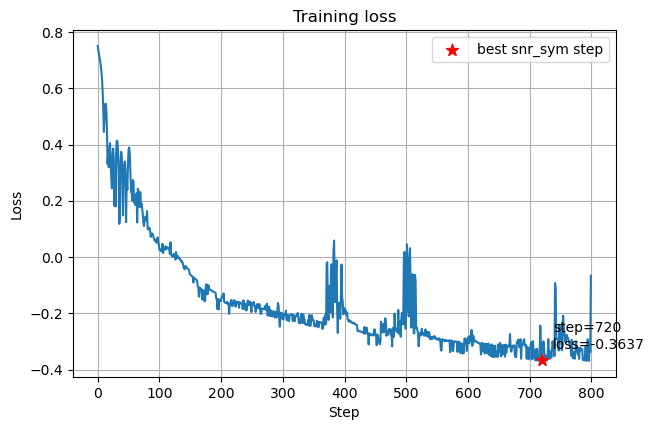

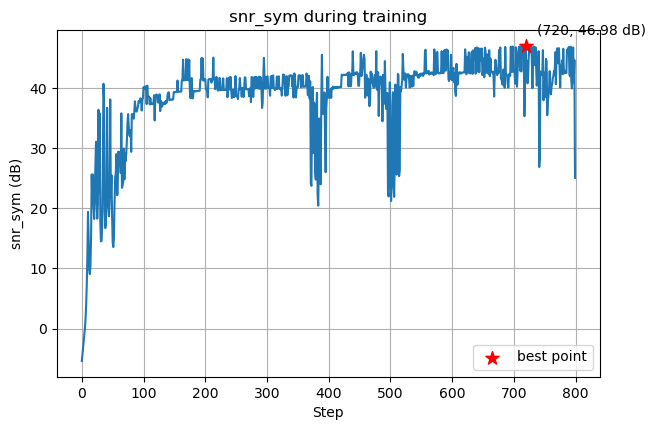

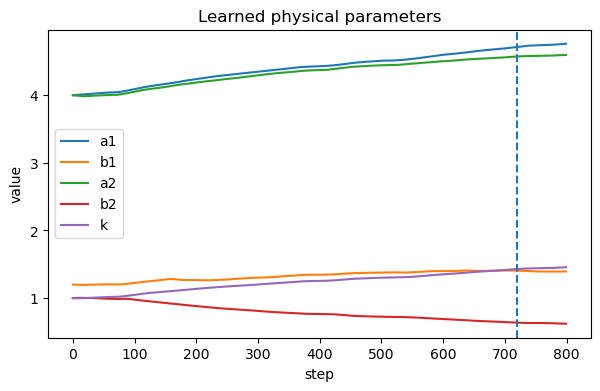

4.714757598904754 1.4062555918378699 4.573745720688655 0.636984745739134 1.4290722823364221


In [10]:
plt.figure(figsize=(7,4.5))



best_step = history_e2e["best_train_snr_sym_step"]
best_loss = history_e2e["loss"][best_step - 1]
plt.scatter(best_step, best_loss, s=80, marker="*",c="#FF0000", label="best snr_sym step",zorder=5)
plt.plot(history_e2e["loss"])
plt.annotate(
    f"step={best_step}\nloss={best_loss:.4f}",
    (best_step, best_loss),
    textcoords="offset points",
    xytext=(8, 8)
)

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training loss")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(7,4.5))
plt.plot(history_e2e["snr_sym_db"])

best_step = history_e2e["best_train_snr_sym_step"]
best_snr = history_e2e["best_train_snr_sym_db"]

plt.scatter(best_step, best_snr, s=100, marker="*", label="best point", c="#FF0000", zorder=5)
plt.annotate(
    f"({best_step}, {best_snr:.2f} dB)",
    (best_step, best_snr),
    textcoords="offset points",
    xytext=(8, 8)
)

plt.xlabel("Step")
plt.ylabel("snr_sym (dB)")
plt.title("snr_sym during training")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(7, 4))
plt.plot(history_e2e["a1"], label="a1")
plt.plot(history_e2e["b1"], label="b1")
plt.plot(history_e2e["a2"], label="a2")
plt.plot(history_e2e["b2"], label="b2")
plt.plot(history_e2e["k"], label="k")
plt.xlabel("step")
plt.ylabel("value")
plt.legend()
plt.axvline(best_step, linestyle="--", linewidth=1.5, label="best snr_sym step")
best_k = history_e2e["k"][best_step - 1]
# plt.scatter(best_step, best_k, s=100, marker="*", label="best point", c="#FF0000", zorder=5)
best_a1 = history_e2e["a1"][best_step - 1]
best_b1 = history_e2e["b1"][best_step - 1]
best_a2 = history_e2e["a2"][best_step - 1]
best_b2 = history_e2e["b2"][best_step - 1]
# plt.scatter(best_step, best_a1, s=100, marker="*", label="best a1", c="#0000FF", zorder=5)
# plt.scatter(best_step, best_b1, s=100, marker="*", label="best b1", c="#00FF00", zorder=5)
# plt.scatter(best_step, best_a2, s=100, marker="*", label="best a2", c="#FFA500", zorder=5)
# plt.scatter(best_step, best_b2, s=100, marker="*", label="best b2", c="#800080", zorder=5)

plt.title("Learned physical parameters")
plt.show()
print(best_a1, best_b1, best_a2, best_b2, best_k)

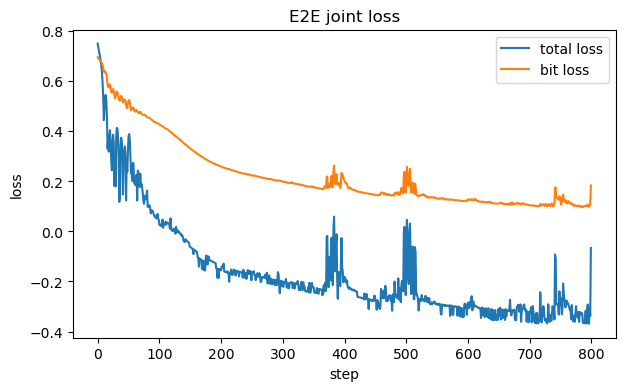

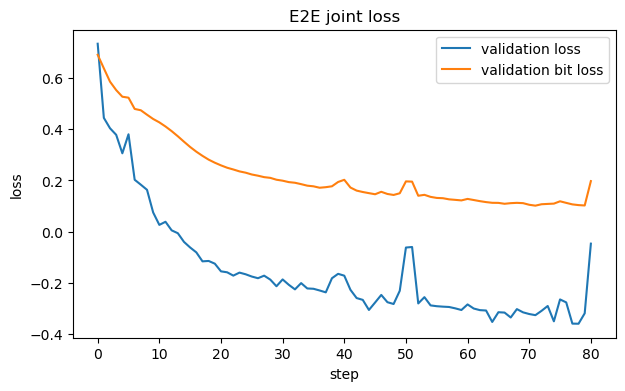

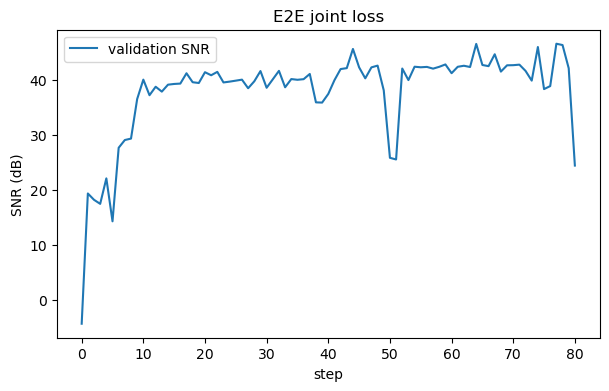

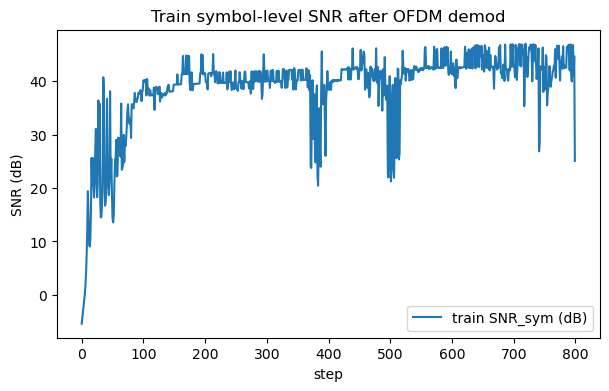

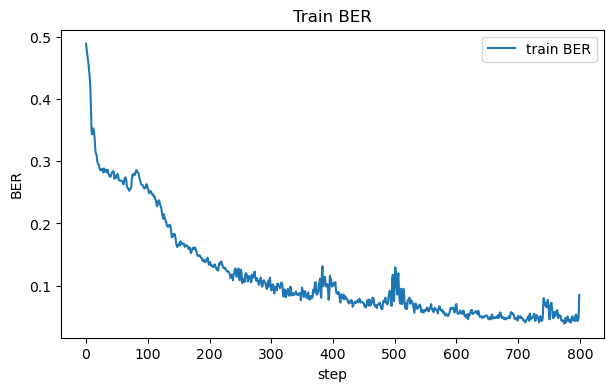

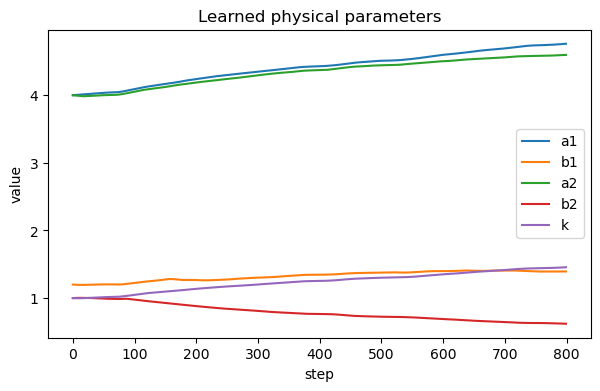

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(history_e2e["loss"], label="total loss")
plt.plot(history_e2e["bit_loss"], label="bit loss")
plt.xlabel("step")
plt.ylabel("loss")
plt.legend()
plt.title("E2E joint loss")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_e2e["val_loss"], label="validation loss")
plt.plot(history_e2e["val_bit_loss"], label="validation bit loss")
plt.xlabel("step")
plt.ylabel("loss")
plt.legend()
plt.title("E2E joint loss")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_e2e["val_snr_sym_db"], label="validation SNR")
plt.xlabel("step")
plt.ylabel("SNR (dB)")
plt.legend()
plt.title("E2E joint loss")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_e2e["snr_sym_db"], label="train SNR_sym (dB)")
plt.xlabel("step")
plt.ylabel("SNR (dB)")
plt.legend()
plt.title("Train symbol-level SNR after OFDM demod")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_e2e["ber"], label="train BER")
plt.xlabel("step")
plt.ylabel("BER")
plt.legend()
plt.title("Train BER")
plt.show()

plt.figure(figsize=(7, 4))

plt.plot(history_e2e["a1"], label="a1")
plt.plot(history_e2e["b1"], label="b1")
plt.plot(history_e2e["a2"], label="a2")
plt.plot(history_e2e["b2"], label="b2")
plt.plot(history_e2e["k"], label="k")
plt.xlabel("step")
plt.ylabel("value")
plt.legend()
plt.title("Learned physical parameters")
plt.show()

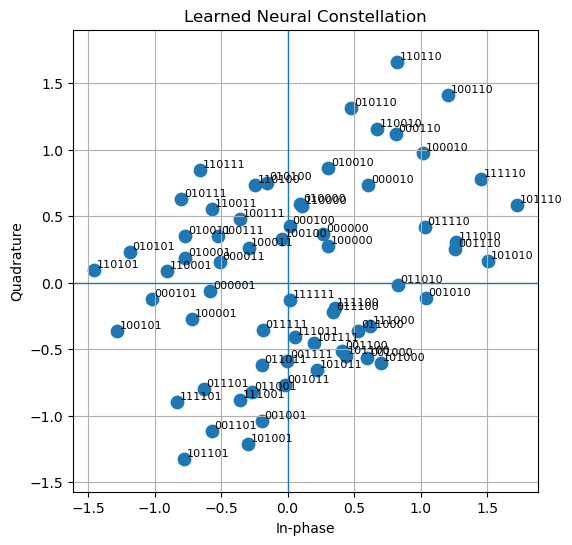

In [14]:
plot_learned_constellation(
    e2e_model.mapper,
    ml=e2e_model.ml,
    annotate=True,
    title="Learned Neural Constellation"
)